# Week 5 - Basic GAN on MNIST using PyTorch

This notebook implements a basic Generative Adversarial Network (GAN) using PyTorch. The model is trained on the MNIST handwritten digit dataset to generate realistic handwritten digit images.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

Using Device: cuda


## Load the MNIST Dataset

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)

print("Dataset Loaded Successfully")

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 481kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.44MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.6MB/s]

Dataset Loaded Successfully


## Define the Generator Network

In [4]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(100,256),
            nn.ReLU(),

            nn.Linear(256,512),
            nn.ReLU(),

            nn.Linear(512,1024),
            nn.ReLU(),

            nn.Linear(1024,784),
            nn.Tanh()
        )

    def forward(self,x):
        x = self.model(x)
        return x.view(-1,1,28,28)

## Define the Discriminator Network

In [5]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Flatten(),

            nn.Linear(784,512),
            nn.LeakyReLU(0.2),

            nn.Linear(512,256),
            nn.LeakyReLU(0.2),

            nn.Linear(256,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.model(x)

In [6]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

print(generator)
print(discriminator)

Generator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): ReLU()
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)
Discriminator(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Linear(in_features=256, out_features=1, bias=True)
    (6): Sigmoid()
  )
)


## Loss Function and Optimizers

In [7]:
criterion = nn.BCELoss()

g_optimizer = optim.Adam(generator.parameters(), lr=0.0002)

d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002)

## Training the GAN

In [8]:
epochs = 5
latent_dim = 100

for epoch in range(epochs):

    for real_images, _ in loader:

        batch_size = real_images.size(0)

        real_images = real_images.to(device)

        real_labels = torch.ones(batch_size,1).to(device)

        fake_labels = torch.zeros(batch_size,1).to(device)

        # --------------------
        # Train Discriminator
        # --------------------

        noise = torch.randn(batch_size, latent_dim).to(device)

        fake_images = generator(noise)

        real_loss = criterion(discriminator(real_images), real_labels)

        fake_loss = criterion(discriminator(fake_images.detach()), fake_labels)

        d_loss = real_loss + fake_loss

        d_optimizer.zero_grad()

        d_loss.backward()

        d_optimizer.step()

        # --------------------
        # Train Generator
        # --------------------

        noise = torch.randn(batch_size, latent_dim).to(device)

        fake_images = generator(noise)

        g_loss = criterion(discriminator(fake_images), real_labels)

        g_optimizer.zero_grad()

        g_loss.backward()

        g_optimizer.step()

    print(f"Epoch {epoch+1}/{epochs} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

Epoch 1/5 | D Loss: 0.0218 | G Loss: 6.1593
Epoch 2/5 | D Loss: 0.5109 | G Loss: 5.5042
Epoch 3/5 | D Loss: 1.5119 | G Loss: 1.5085
Epoch 4/5 | D Loss: 0.2673 | G Loss: 2.4346
Epoch 5/5 | D Loss: 0.4197 | G Loss: 3.0689


## Generate New Images

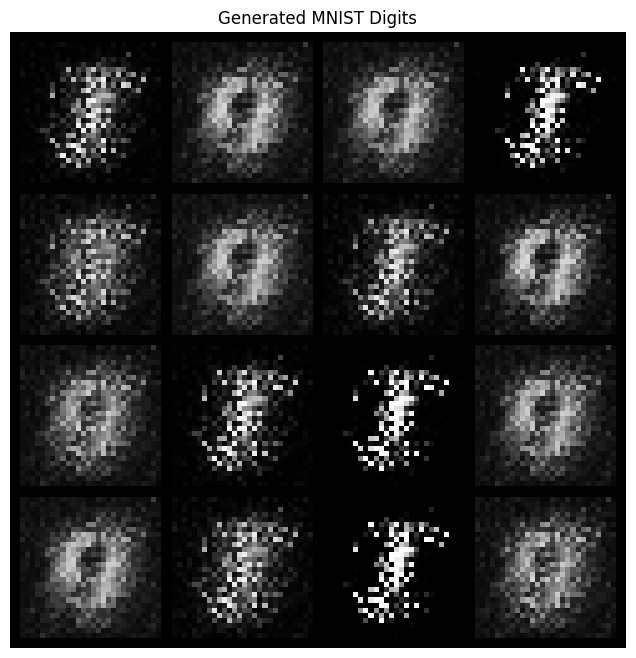

In [9]:
noise = torch.randn(16,100).to(device)

generated = generator(noise).cpu().detach()

grid = make_grid(generated,nrow=4,normalize=True)

plt.figure(figsize=(8,8))
plt.imshow(grid.permute(1,2,0))
plt.axis("off")
plt.title("Generated MNIST Digits")
plt.show()

## Save the Generator Model

In [10]:
torch.save(generator.state_dict(),"generator.pth")

print("Generator model saved successfully.")

Generator model saved successfully.


## Summary

In this notebook, we:

- Loaded the MNIST dataset.
- Built the Generator and Discriminator networks.
- Defined the adversarial loss function.
- Trained the GAN.
- Generated handwritten digit images.
- Saved the trained Generator model.

This implementation demonstrates the complete workflow of a basic GAN using PyTorch.